# Predicting Laptop Prices with ML

In [46]:
# import 

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


In [6]:
df = pd.read_csv('data/Laptop_price.csv')
df

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718
...,...,...,...,...,...,...,...
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459


In [7]:
df.head(3)

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [10]:
df['Brand'].unique()

array(['Asus', 'Acer', 'Lenovo', 'HP', 'Dell'], dtype=object)

# EDA

In [12]:
df.isna().sum().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#статистика датасета

df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [18]:
number_data = df.select_dtypes(include=['number'])

In [20]:
number_data.corr()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
Processor_Speed,1.000000,0.021391,-0.067576,-0.013425,-0.054603,-0.050737
RAM_Size,0.021391,1.000000,0.002111,-0.036002,-0.025382,0.061237
Storage_Capacity,-0.067576,0.002111,1.000000,-0.027560,0.041335,0.997908
Screen_Size,-0.013425,-0.036002,-0.027560,1.000000,0.021995,-0.026740
Weight,-0.054603,-0.025382,0.041335,0.021995,1.000000,0.038417
Price,-0.050737,0.061237,0.997908,-0.026740,0.038417,1.000000


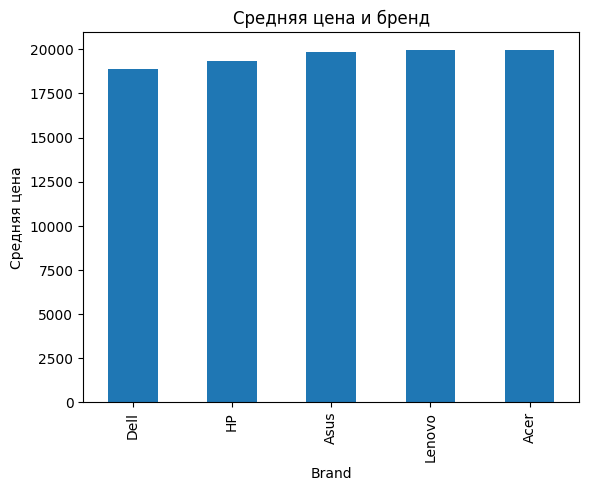

In [27]:
df.groupby('Brand')['Price'].mean().sort_values(ascending = True).plot(kind = 'bar')
plt.title('Средняя цена и бренд')
plt.ylabel('Средняя цена')
plt.show()

In [32]:
df.groupby('RAM_Size')['Brand'].value_counts().reset_index()

,RAM_Size,Brand,count
0,4,HP,59
1,4,Acer,50
2,4,Dell,48
3,4,Asus,47
4,4,Lenovo,39
5,8,Asus,66
6,8,Lenovo,51
7,8,Acer,48
8,8,Dell,43
9,8,HP,38


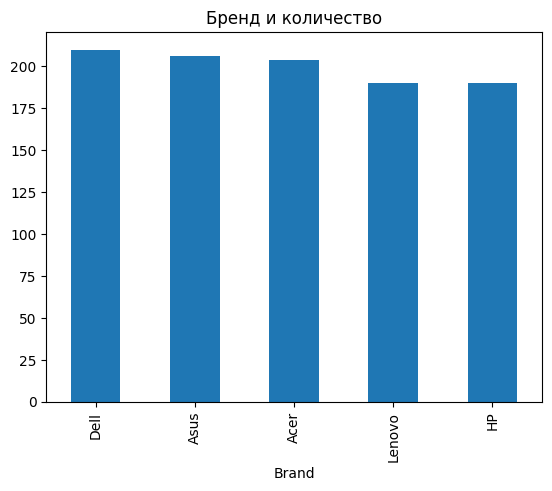

In [37]:
df['Brand'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.title('Бренд и количество')
plt.show()

# Создание и обучние модели

In [38]:
df.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')

In [39]:
y = df['Price']
X = df[['Processor_Speed', 'RAM_Size', 'Storage_Capacity']]

In [40]:
X

,Processor_Speed,RAM_Size,Storage_Capacity
0,3.830296,16,512
1,2.912833,4,1000
2,3.241627,4,256
3,3.806248,16,512
4,3.268097,32,1000
...,...,...,...
995,3.343584,4,1000
996,2.780555,8,256
997,3.200569,4,512
998,1.604182,8,256


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
model_rf = RandomForestRegressor()


In [51]:
param_grid = {'max_depth' : [2, 5, 10, 15, 20, 25], 
              'max_features' : ['auto', 'log2'],
              'n_estimators' : [2, 4, 6, 8, 10, 12]}

In [52]:
grid_rf = GridSearchCV(model_rf, param_grid)

In [53]:
grid_rf.fit(X_train, y_train)

/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
  File "/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/sklearn/base.py", line 469, in _validate

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [2, 5, ...], 'max_features': ['auto', 'log2'], 'n_estimators': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,8


In [54]:
grid_rf.best_params_

{'max_depth': 15, 'max_features': 'log2', 'n_estimators': 8}

In [55]:
predictions = grid_rf.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error

In [57]:
mean_absolute_error(y_test, predictions)

469.94980719900923